In [8]:
"""
Do Thresholded NNLSR..

Investigate applying gaussian filter series -> image. Can we better pick out where the events should be or the correct local sum?

Investigate General filtering...? Seperate File?
We could also try to create our own optimal filter based on frequencies present in the kernel vs gaussian noise..

"""

'\nDo Thresholded NNLSR..\n\nInvestigate applying gaussian filter series -> image. Can we better pick out where the events should be or the correct local sum?\n\nInvestigate General filtering...? Seperate File?\nWe could also try to create our own optimal filter based on frequencies present in the kernel vs gaussian noise..\n\n'

In [9]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from copy import deepcopy

from util.DataGen import nai_pulse, plastic_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import threshold_nnlsr_deconvolve

In [10]:
sensor_type = 'NaI'
assert sensor_type in ['NaI', 'plastic']

# Trace Parameters
keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise= .5 # mV
bits = 24
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 1E-5
# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007, #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

countrate = 4E6

if sensor_type == 'plastic':
    _, kernel = plastic_pulse(1)
    spectrum = np.loadtxt('../original/LgPl_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/LgPl_Response', usecols=(0), dtype=float)  # in kev
else:
    _, kernel = nai_pulse(1, 101)
    spectrum = np.loadtxt('../original/NaI_Response', usecols=(1), dtype=float)
    bins = 1E3 * np.loadtxt('../original/NaI_Response', usecols=(0), dtype=float)  # in kev

common_trace_kwargs = {
    'trace_type': 'constant',
    'keV_per_area' : keV_per_area,
    'mV_per_ADC' : mV_per_ADC,
    'baseline' : baseline, # mV
    'basenoise': basenoise, # mV
    'bits' : bits,
    'clip_magnitude' : clip, # mV
    'fs' : fs, # new HERA sampling rate
    'total_time' : total_time,
    'spectrum_hist': spectrum,
    'detector_response_kernel': kernel,
    'spectrum_bin_energies':bins,
    # for Lognormal traces
    'lognormal_fwhm' : fwhm, #50.0 #fwhm of the total TGF count distribution in units microseconds
    'lognormal_mean' : mean, #.7 #mean of the TGF trace distribution
    'lognormal_std' : std, #.5 #determines the amount of assymetry in the TGF trace distribution
    'return_object':True,
    'count_rate': int(countrate)
}

out = continuous_time_trace(**common_trace_kwargs)
trace = out.trace
true_volts = out.event_voltages
true_samples = out.event_times * fs


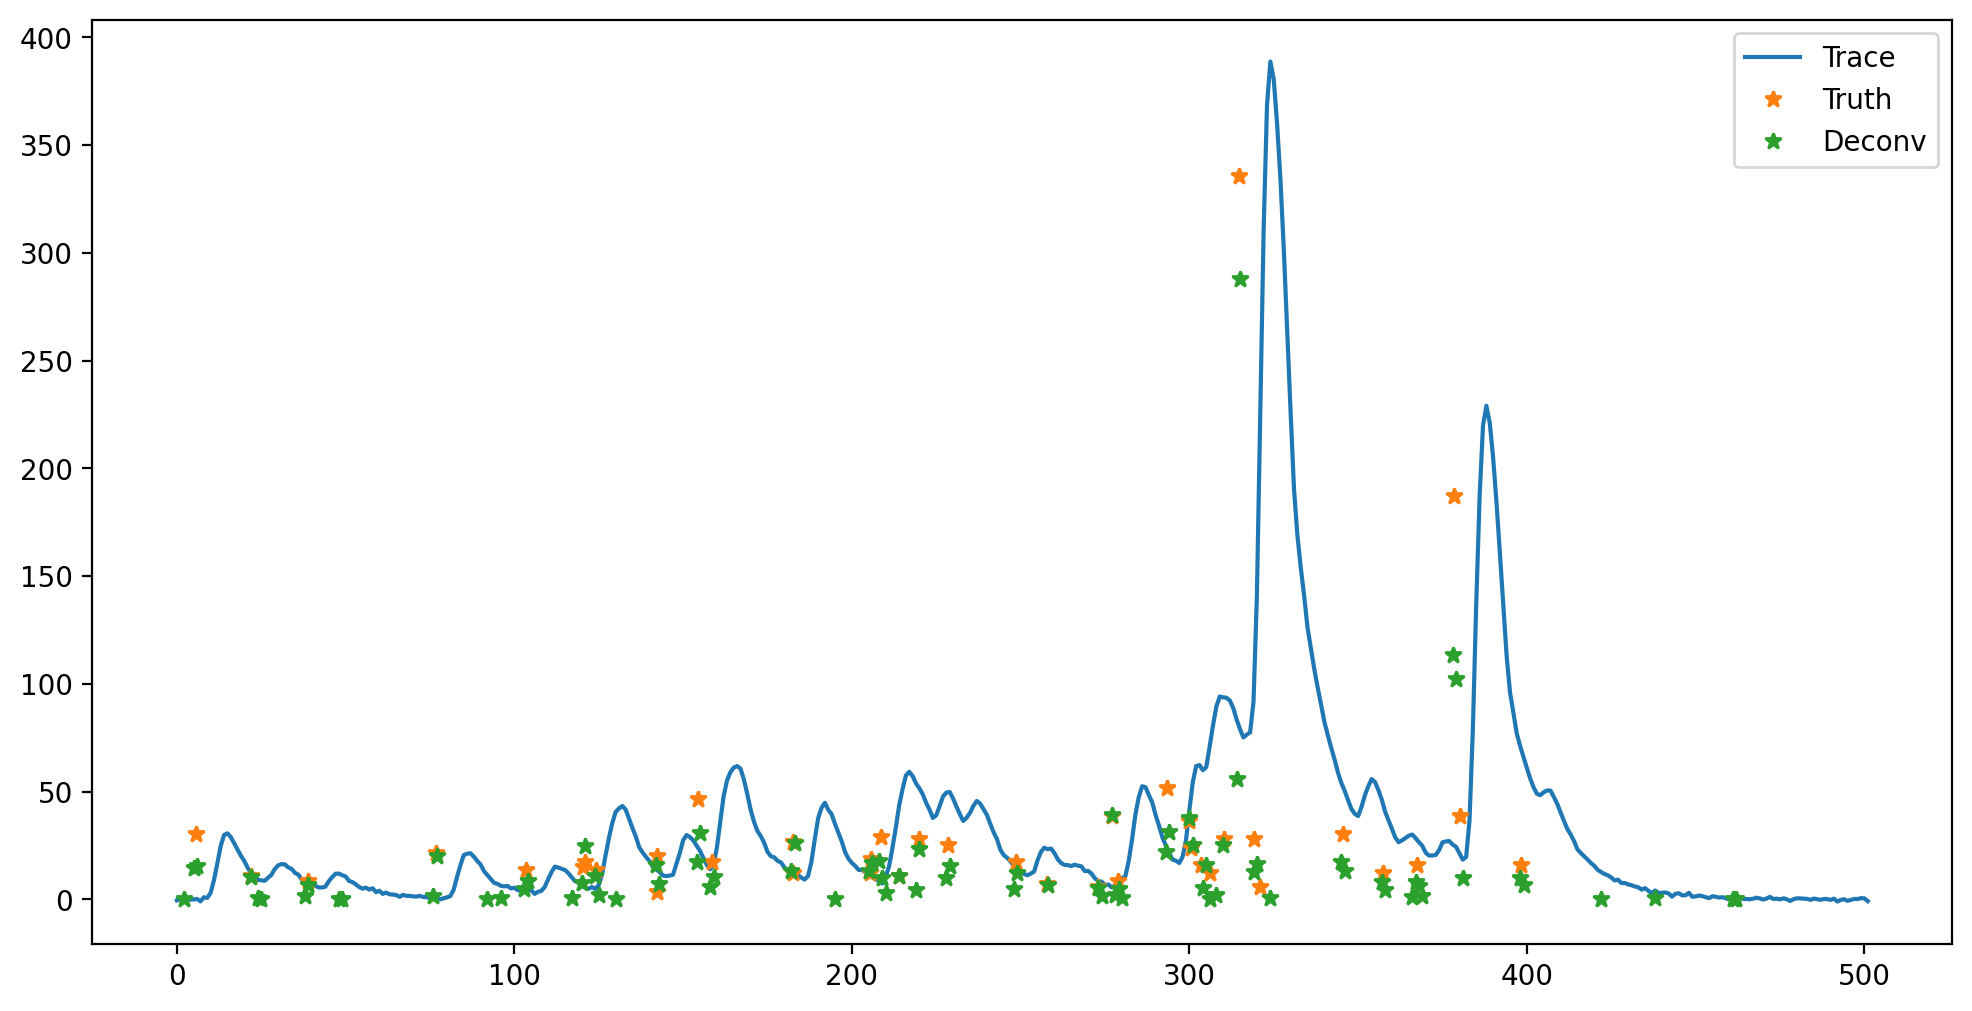

In [11]:
deconv_volts, deconv_samples = threshold_nnlsr_deconvolve(y=trace, kernel=kernel, threshold=0)
deconv_trace = np.zeros_like(trace)
deconv_trace[deconv_samples] = deconv_volts

fig, axes = plt.subplots(1,1, figsize=(12, 6), dpi=200)
axes.plot(trace, label='Trace')
axes.plot(true_samples, true_volts, '*',  label='Truth')
axes.plot(deconv_samples, deconv_volts, '*', label='Deconv')

axes.legend()



/tmp/ipykernel_9304/1401918866.py:21: RuntimeWarning: divide by zero encountered in log2
  axes.imshow(np.log2(convsum_trace_image), interpolation='none', origin='lower', aspect='auto')


(0.0, 500.0)

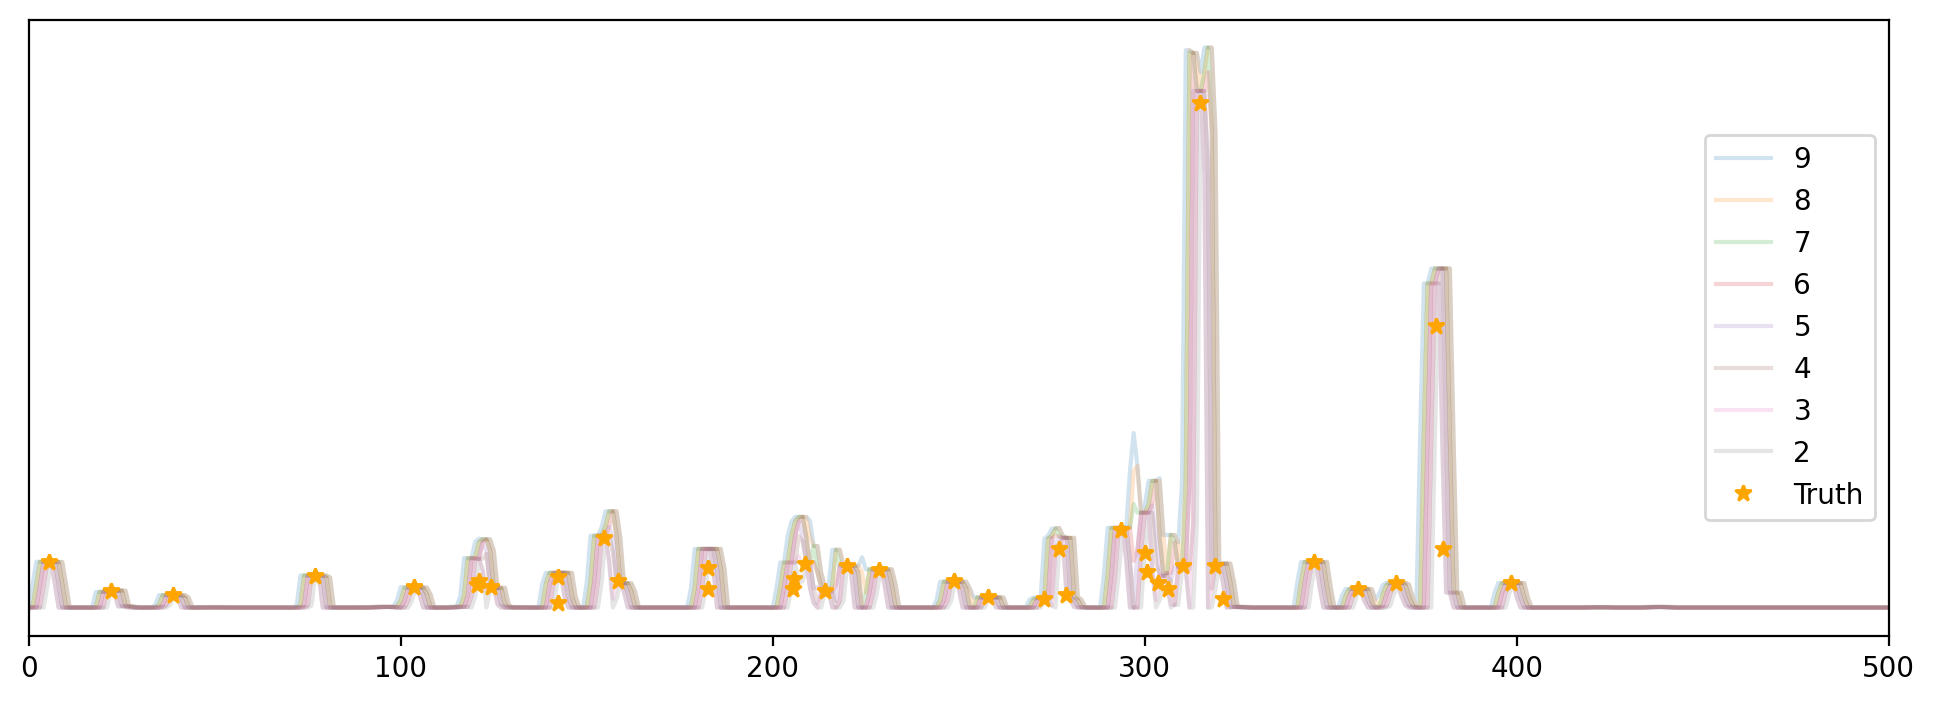

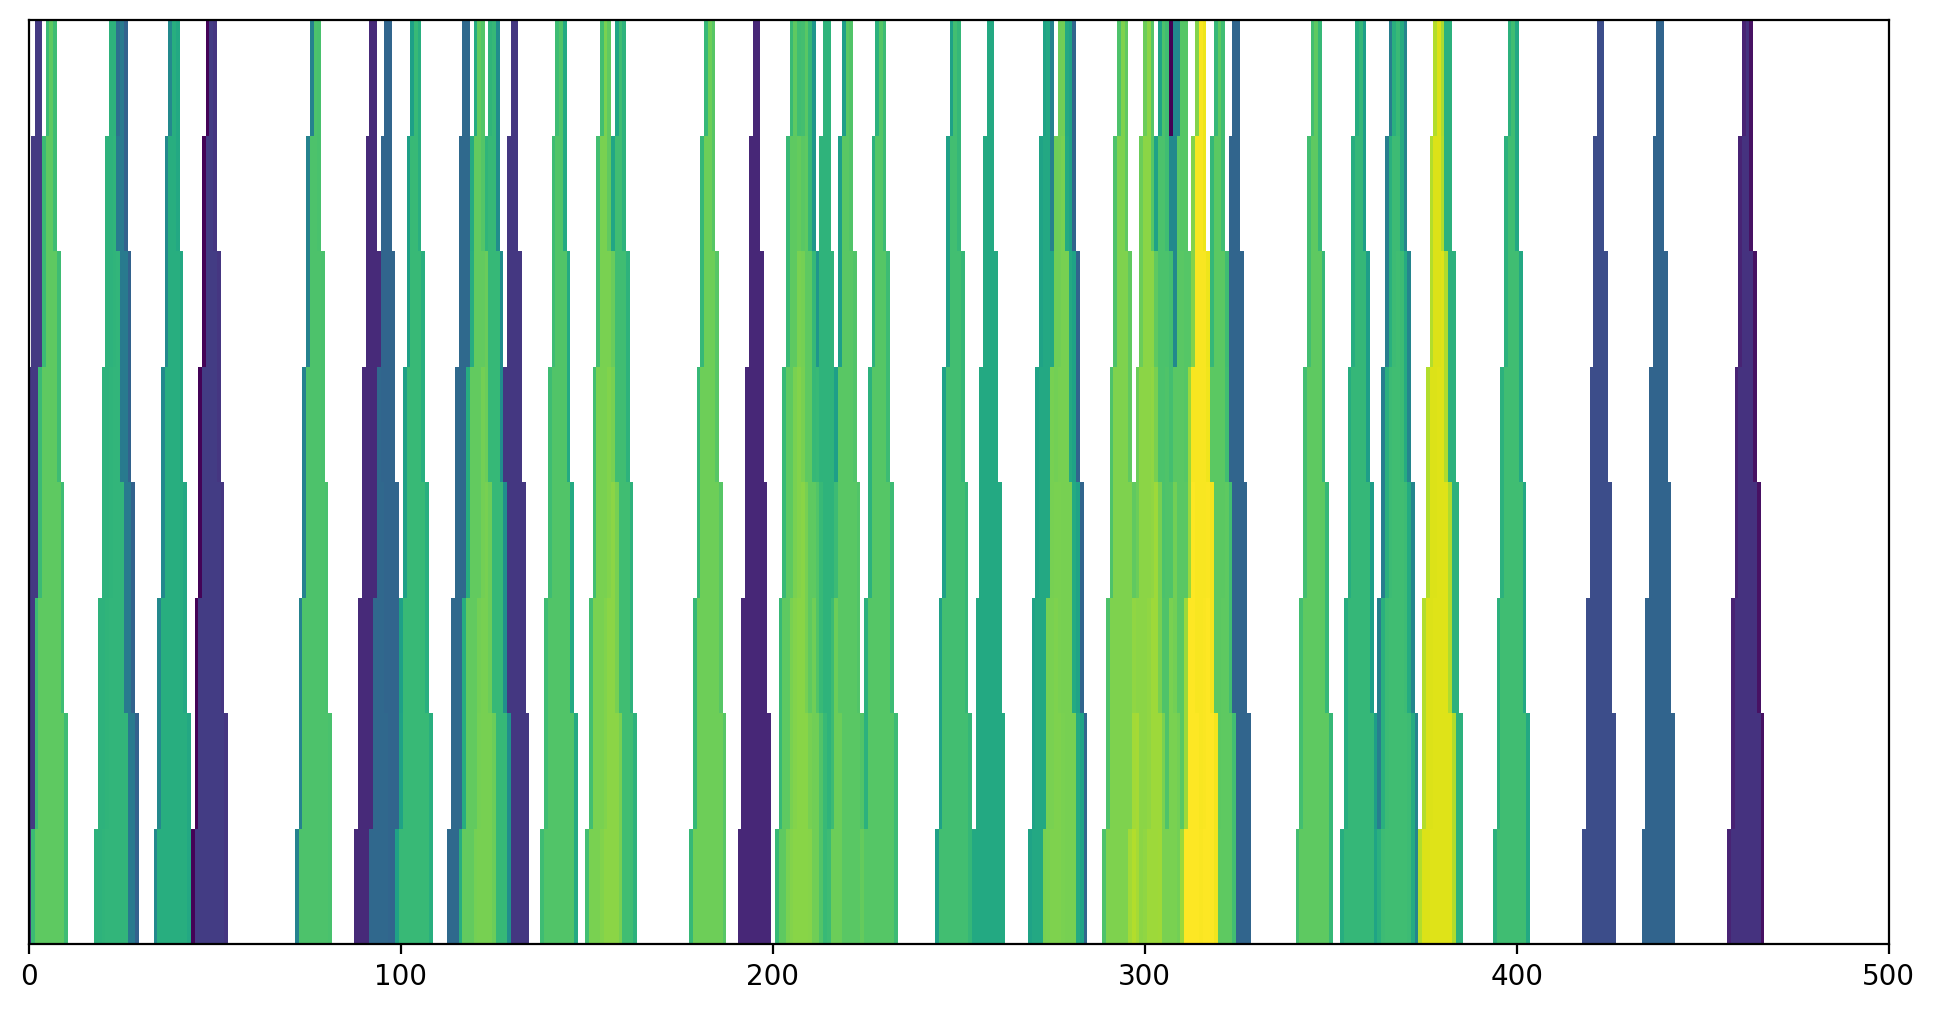

In [12]:
sum_lengths = np.arange(2, 10)[::-1]

convsum_trace_image = np.zeros((sum_lengths.size, trace.size))
for i, sl in enumerate(sum_lengths.tolist()):
    convsum_trace_image[i,:] = np.convolve(deconv_trace, np.ones(sl), mode='same')
    
    
fig, axes = plt.subplots(1,1, figsize=(12, 4), dpi=200)
axes.set_xlim(0, trace.size)
for i, sl in enumerate(sum_lengths.tolist()):
    axes.plot(convsum_trace_image[i,:], label=sl, alpha=.2)
axes.plot(true_samples, true_volts, marker='*', linestyle='', color='orange', label='Truth')
axes.legend(loc='right')
axes.set_yticks([])

lim = (0, 500)
axes.set_xlim(lim)
    
    
fig, axes = plt.subplots(1,1, figsize=(12, 6), dpi=200)
axes.imshow(np.log2(convsum_trace_image), interpolation='none', origin='lower', aspect='auto')
axes.set_yticks([]) 
axes.set_xlim(lim)


In [13]:
# sigmas = np.linspace(.5, 5, 21)
# smoothed_trace_image = np.zeros((sigmas.size, trace.size))
# 
# for i, sigma in enumerate(sigmas.tolist()):
#     smoothed_trace_image[i,:] = scipy.ndimage.gaussian_filter1d(deconv_trace, sigma=sigma)
# 
# fig, axes = plt.subplots(1,1, figsize=(12, 2), dpi=200)
# for i, sigma in enumerate(sigmas.tolist()):
#     axes.plot(smoothed_trace_image[i,:])
#     
# fig, axes = plt.subplots(1,1, figsize=(12, 6), dpi=200)
# axes.imshow(smoothed_trace_image, interpolation='none', origin='lower', aspect='auto')